In [14]:
import numpy as np
import pandas as pd

In [15]:
df = pd.read_csv("powerplant_data.csv")

In [16]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [19]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [21]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [23]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
df.shape

(9568, 5)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
# Convert data into tensors
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=float)
y_train_tensor = torch.tensor(y_train.values, dtype=float).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=float)
y_test_tensor = torch.tensor(y_test.values, dtype=float).view(-1, 1)


In [31]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [32]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Deep Learning

In [33]:
# Defining the ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # Output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [34]:
import torch.optim as optim

model = ANN()

# Loss, Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [22]:
# Training the ANN
train_losses = []
val_losses = []

epochs = 25

for epoch in range(epochs):
    model.train()
    running_loss = 0.0  # total training loss for 1 epoch

    for xb, yb in train_loader:       # xb, yb = features and labels in 1 batch
        xb = xb.float()
        yb = yb.float()
        optimizer.zero_grad()

        outputs = model(xb)           # forward prop---predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward()               # back prop---compute gradients
        optimizer.step()              # params update

        running_loss += loss.item()   # loss is a tensor -> py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():    # no gradients compute
        for xb, yb in test_loader:
            xb = xb.float()
            yb = yb.float()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

Epoch 1/25 ==> train loss = 20.614030679066975 & val loss = 18.85184097290039
Epoch 2/25 ==> train loss = 20.695214676856995 & val loss = 18.87050437927246
Epoch 3/25 ==> train loss = 20.739191097021102 & val loss = 18.732473373413086
Epoch 4/25 ==> train loss = 20.607910799980164 & val loss = 18.665264129638672
Epoch 5/25 ==> train loss = 20.626850134134294 & val loss = 18.695289611816406
Epoch 6/25 ==> train loss = 20.63416866461436 & val loss = 18.69732666015625
Epoch 7/25 ==> train loss = 20.65967758099238 & val loss = 18.88112449645996
Epoch 8/25 ==> train loss = 20.7397100965182 & val loss = 18.767826080322266
Epoch 9/25 ==> train loss = 20.658018241326015 & val loss = 18.994386672973633
Epoch 10/25 ==> train loss = 20.595270256201427 & val loss = 18.77988624572754
Epoch 11/25 ==> train loss = 20.629008636871973 & val loss = 18.886445999145508
Epoch 12/25 ==> train loss = 20.687317057450613 & val loss = 18.702741622924805
Epoch 13/25 ==> train loss = 20.638784368832905 & val loss

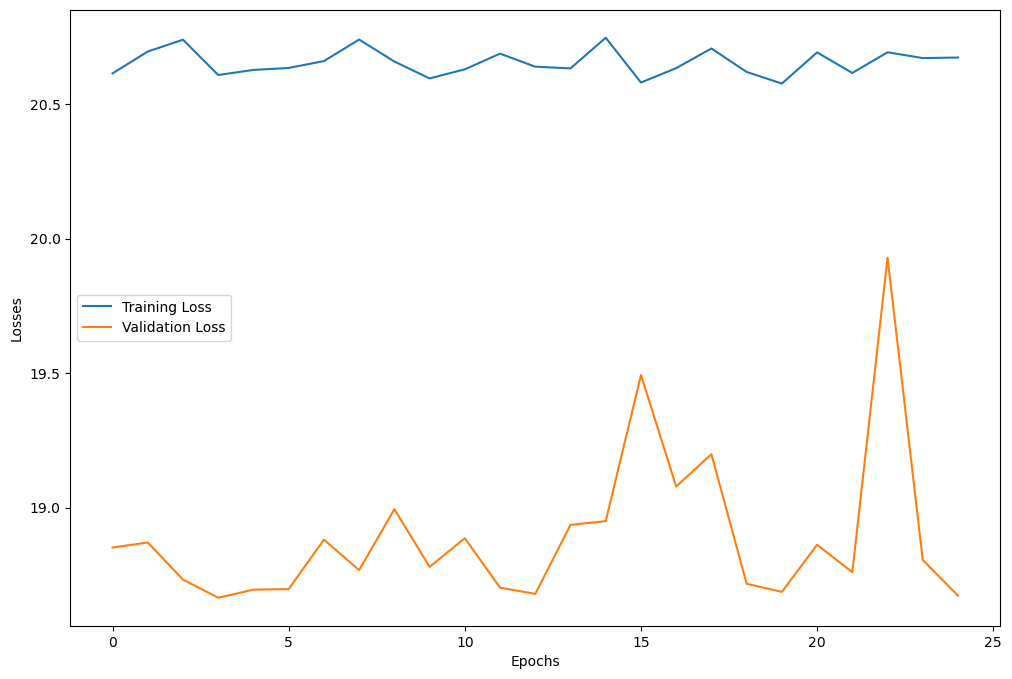

In [23]:
# Visualize the losses
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss" : train_losses,
    "Validation Loss" : val_losses
})

plt.figure(figsize=(12, 8))
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()